In [6]:
import logging
from tmu.models.classification.vanilla_classifier import TMClassifier
import os
import config
import pickle
import numpy as np
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_otsu_thresholding_booleanization
from utils.training import train_tm_and_save_scores
from utils.clause_visualization import visualize_average_heatmap, visualize_per_channel_heatmaps, number_of_literals_in_clause, get_correct_sample_index, visualize_aggregated_heatmap, build_save_path, load_raw_maps_and_plot_heatmap

In [7]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
CURRENT_SPECIALIST = config.OTSU
CURRENT_DATASET = config.PNEUMONIAMNIST
CURRENT_RESOLUTION = 1 
specialist_name = ["Otsu"]

In [8]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [9]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_otsu_thresholding_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test)

In [10]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)
Y_val = Y_val.astype(np.uint32)

In [6]:
study = run_tm_optuna_search(TMClassifier, config, X_train, Y_train, X_val, Y_val, metric="fbeta", pos_label=1)

[I 2026-03-16 20:12:51,791] A new study created in memory with name: no-name-1fd76060-6461-420b-9e22-355cf9b998d0


[I 2026-03-16 21:05:55,838] Trial 0 finished with value: 0.9397715472481828 and parameters: {'s': 6.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.9397715472481828.


[I 2026-03-16 22:03:45,588] Trial 1 finished with value: 0.9331259720062208 and parameters: {'s': 1.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.9397715472481828.


[I 2026-03-16 23:06:08,006] Trial 2 finished with value: 0.9732234809474768 and parameters: {'s': 10.0, 'T': 2000, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 2 with value: 0.9732234809474768.


[I 2026-03-17 00:05:04,866] Trial 3 finished with value: 0.9591520165460186 and parameters: {'s': 10.0, 'T': 2500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 2 with value: 0.9732234809474768.


...

[I 2026-03-18 20:27:44,077] Trial 46 finished with value: 0.9679917398038204 and parameters: {'s': 11.0, 'T': 9500, 'patch_size': 9, 'max_included_literals': 32}. Best is trial 2 with value: 0.9732234809474768.


[I 2026-03-18 21:35:09,345] Trial 47 finished with value: 0.9513960703205792 and parameters: {'s': 6.0, 'T': 7500, 'patch_size': 5, 'max_included_literals': 512}. Best is trial 2 with value: 0.9732234809474768.


[I 2026-03-18 22:42:51,246] Trial 48 finished with value: 0.9601449275362319 and parameters: {'s': 8.0, 'T': 10000, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 2 with value: 0.9732234809474768.


[I 2026-03-18 23:27:19,670] Trial 49 finished with value: 0.9470679813181111 and parameters: {'s': 13.0, 'T': 7000, 'patch_size': 7, 'max_included_literals': 32}. Best is trial 2 with value: 0.9732234809474768.


Best fbeta: 0.9732234809474768
Best hyperparameters: {'s': 10.0, 'T': 2000, 'patch_size': 9, 'max_included_literals': 128}


In [7]:
best_params = study.best_params
print("Best F1 score macro accuracy:", study.best_value)
print("Best hyperparameters:", best_params)
save_optuna_best_results(study, "hyperparameters/otsu.json")

Best F1 score macro accuracy: 0.9732234809474768
Best hyperparameters: {'s': 10.0, 'T': 2000, 'patch_size': 9, 'max_included_literals': 128}
Best Optuna results saved to hyperparameters/otsu.json


In [12]:
best_value, best_params = load_optuna_best_results("hyperparameters/otsu.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [9]:
tm = train_tm_and_save_scores(
    TMClassifier=TMClassifier,
    config=config,
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    T=T_best,
    s=s_best,
    patch_dim=patch_best,
    max_included_literals=maxlit_best,
    weighted_clauses=weighted_best,
    specialist_name="PneumoniaMNIST_Otsu",
    save_dir=config.SAVE_DIR_SCORES,
)


Accuracy over 100 epochs:



#1 Accuracy: 82.85% (98.47s)


#2 Accuracy: 85.74% (90.42s)


#3 Accuracy: 85.26% (88.24s)


#4 Accuracy: 85.10% (87.02s)


...

#96 Accuracy: 86.22% (79.99s)


#97 Accuracy: 85.90% (79.87s)


#98 Accuracy: 85.74% (80.04s)


#99 Accuracy: 86.38% (80.19s)


#100 Accuracy: 86.86% (79.82s)


In [13]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "PneumoniaMNIST_Otsu_Specialist.pkl")

In [11]:
if not os.path.exists(model_path):
    with open(model_path, "wb") as f:
        pickle.dump(tm, f)
    print("Model saved.")
else:
    print("Model already exists. Skipping save.")

Model saved.


In [14]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

Test Accuracy: 86.86%
2026-05-10 20:17:59,852 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x762e56276960>


Saved to saved_confusion_matrices/pneumonia_otsu.svg


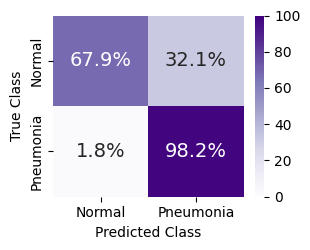

In [16]:
_, _ = plot_confusion_matrix_from_scores(config=config,  T= T_best, s= s_best, patch_size= patch_best, max_lit= maxlit_best, weighted= weighted_best, 
                                   Y_true=Y_test, specialist_name="PneumoniaMNIST_Otsu", dataset_name=CURRENT_DATASET, save_specialist_name=CURRENT_SPECIALIST, figsize=(3.2, 2.6), annot_fontsize=14, cmap = "Purples") 

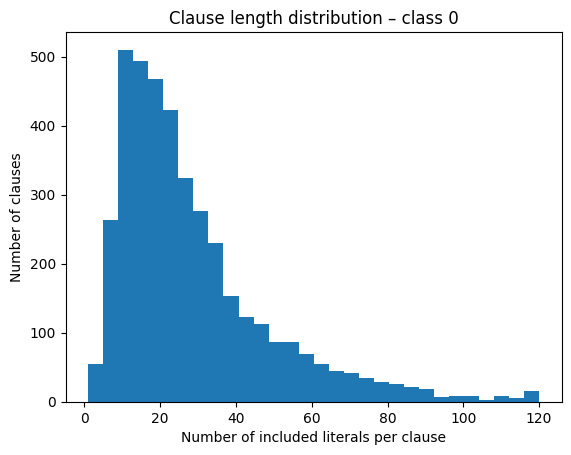

Class 0: median=22.0, mean=28.2, std=20.3


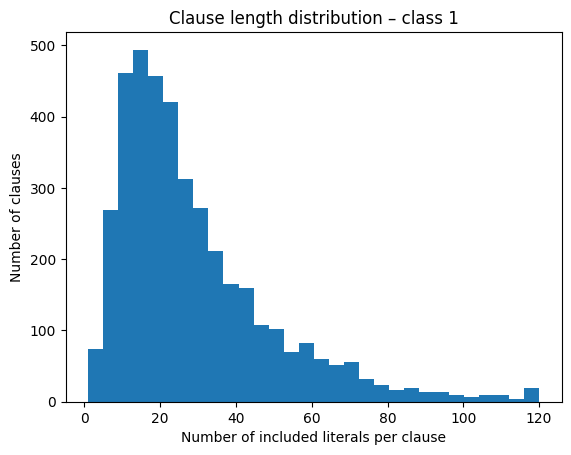

Class 1: median=23.0, mean=28.6, std=20.6


In [14]:
_ = plot_clause_length_distribution(tm)

Test Accuracy: 86.86%
2026-03-27 22:02:27,071 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-03-27 22:02:27,074 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.


2026-03-27 22:02:27,096 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x76bc581bbe90>


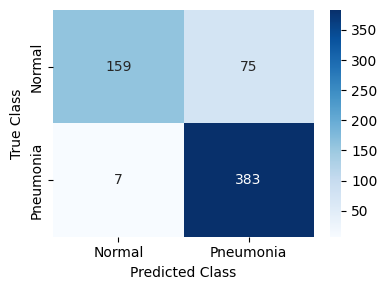

In [9]:
_, _ = plot_confusion_matrix_from_scores(config,  T_best, s_best, patch_best, maxlit_best, weighted_best, 
                                   Y_test, "PneumoniaMNIST_Otsu", figsize=(4,3)) 

# Class 0 Local Examples

In [9]:
for i in range(3):
    image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=0, random=True)
    print(f"Selected image index: {image_index}")
    print(f"True class: {Y_test[image_index]}")
    print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 136
True class: 0
Predicted class: 0
Selected image index: 384
True class: 0
Predicted class: 0
Selected image index: 558
True class: 0
Predicted class: 0


0
2026-04-10 15:28:43,292 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 15:28:43,297 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 136  |  predicted class: 0
2026-04-10 15:28:43,331 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x75ca70b75ac0>
Saved to saved_heatmaps/otsu/pneumonia_otsu_lh_c0_s136_aggr.svg


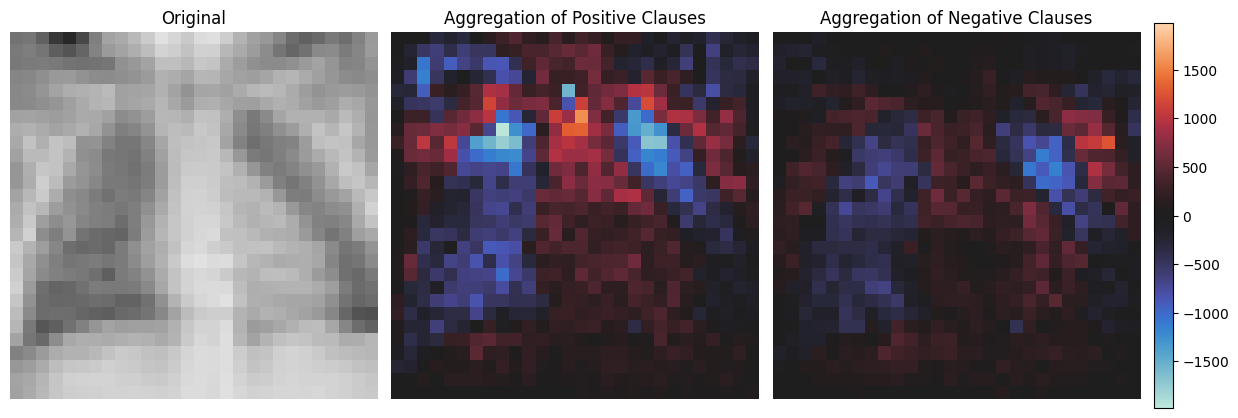

Visualizing sample 136  |  predicted class: 0
2026-04-10 15:28:46,590 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x75ca70112c90>
Saved to saved_heatmaps/otsu/pneumonia_otsu_lh_c0_s136_chan.svg


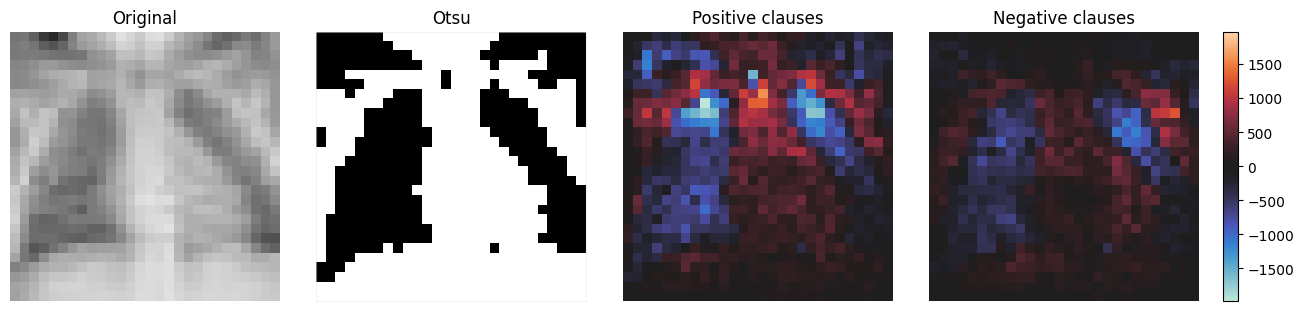

In [9]:
image_index =  136
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

0
Visualizing sample 384  |  predicted class: 0
2026-04-10 15:28:50,066 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x75ca701f7b90>
Saved to saved_heatmaps/otsu/pneumonia_otsu_lh_c0_s384_aggr.svg


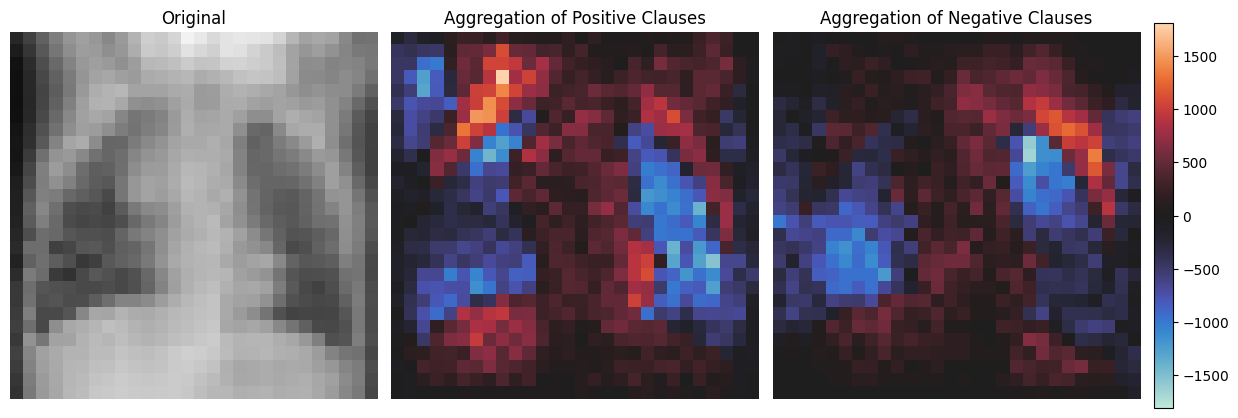

Visualizing sample 384  |  predicted class: 0
2026-04-10 15:28:53,383 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x75ca502ce300>
Saved to saved_heatmaps/otsu/pneumonia_otsu_lh_c0_s384_chan.svg


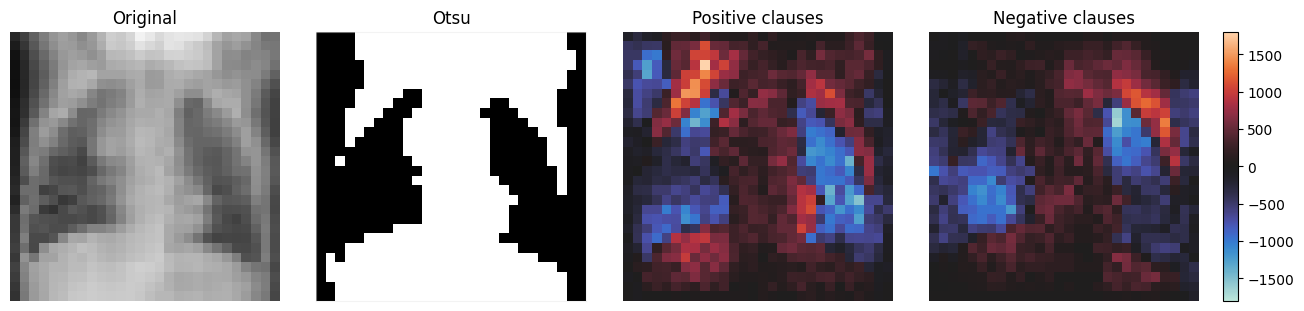

In [10]:
image_index =  384
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

0


Visualizing sample 558  |  predicted class: 0
2026-04-10 15:28:56,672 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x75ca4a9e1f40>
Saved to saved_heatmaps/otsu/pneumonia_otsu_lh_c0_s558_aggr.svg


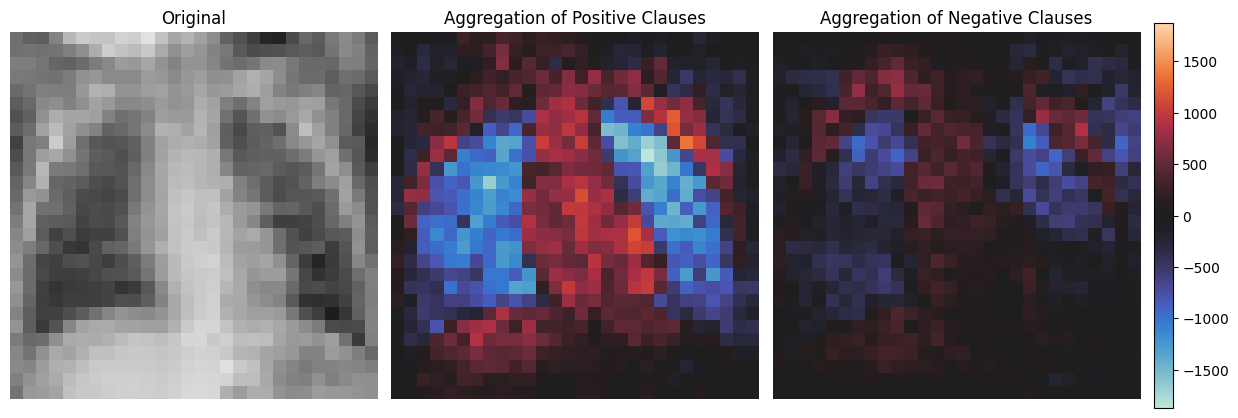

Visualizing sample 558  |  predicted class: 0
2026-04-10 15:29:00,029 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x75ca4a80a000>
Saved to saved_heatmaps/otsu/pneumonia_otsu_lh_c0_s558_chan.svg


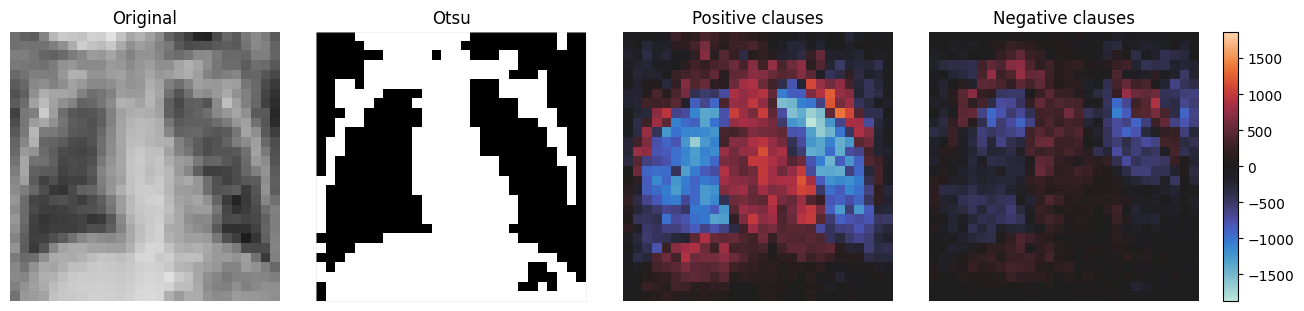

In [11]:
image_index =  558
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

# Class 1 Local Examples 

In [13]:
for i in range(3):
    image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=1, random=True)
    print(f"Selected image index: {image_index}")
    print(f"True class: {Y_test[image_index]}")
    print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 140
True class: 1
Predicted class: 1
Selected image index: 344
True class: 1
Predicted class: 1
Selected image index: 295
True class: 1
Predicted class: 1


1


Visualizing sample 140  |  predicted class: 1
2026-04-10 15:29:03,193 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x75ca4a6710a0>
Saved to saved_heatmaps/otsu/pneumonia_otsu_lh_c1_s140_aggr.svg


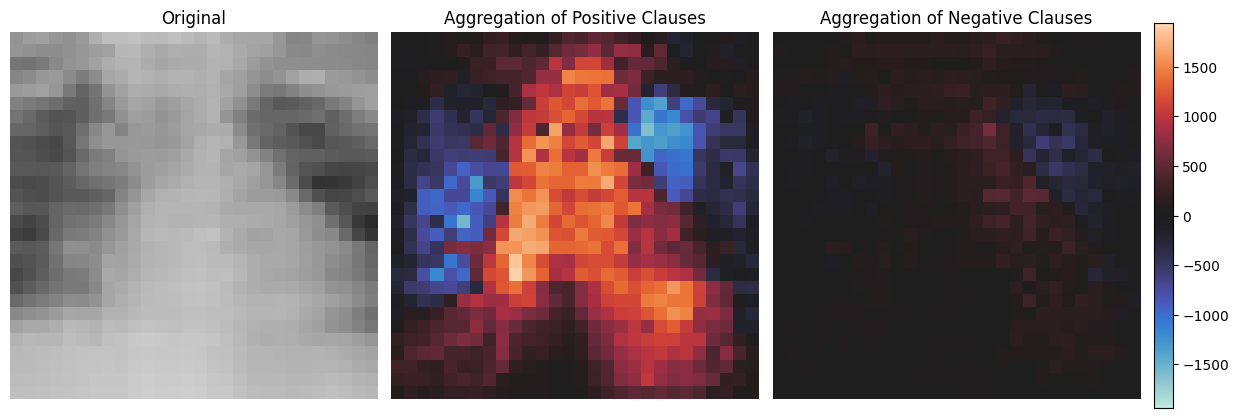

Visualizing sample 140  |  predicted class: 1
2026-04-10 15:29:06,653 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x75ca4a4008f0>
Saved to saved_heatmaps/otsu/pneumonia_otsu_lh_c1_s140_chan.svg


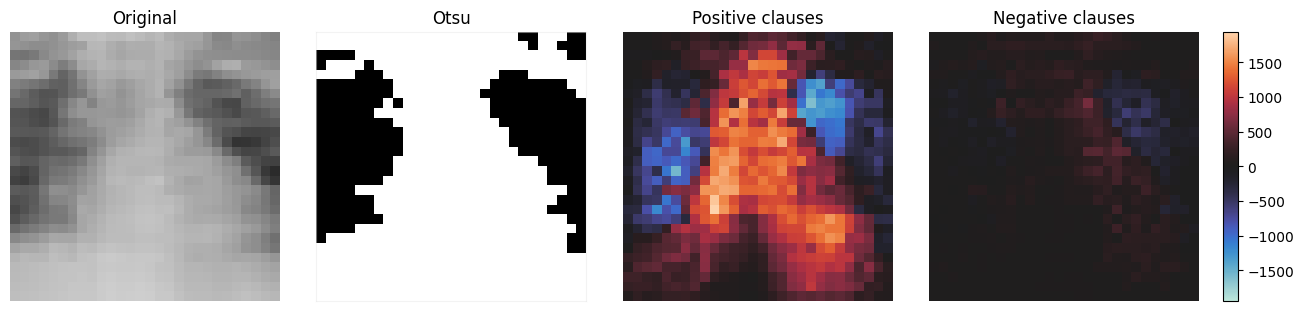

In [12]:
image_index =  140
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

1
Visualizing sample 344  |  predicted class: 1
2026-04-10 15:29:10,076 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x75ca4a30be30>
Saved to saved_heatmaps/otsu/pneumonia_otsu_lh_c1_s344_aggr.svg


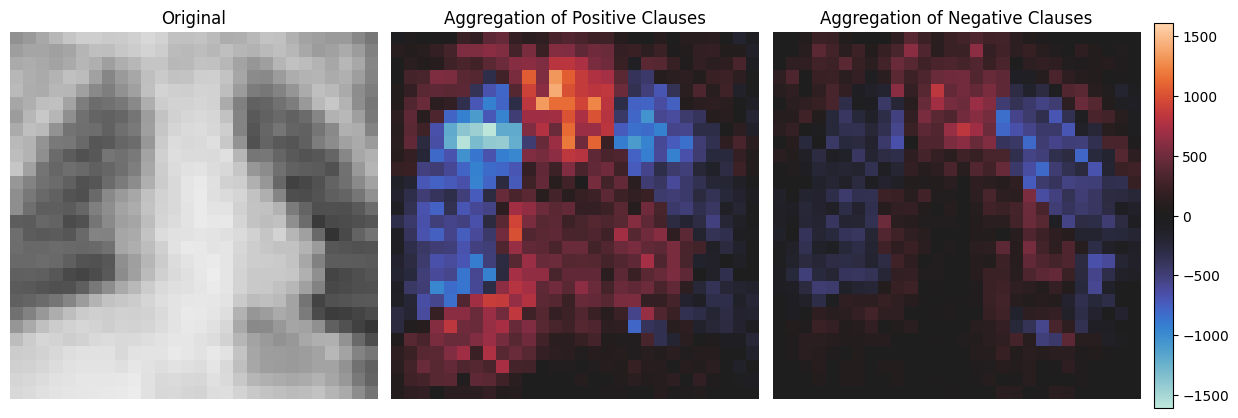

Visualizing sample 344  |  predicted class: 1
2026-04-10 15:29:13,635 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x75ca4a330e90>
Saved to saved_heatmaps/otsu/pneumonia_otsu_lh_c1_s344_chan.svg


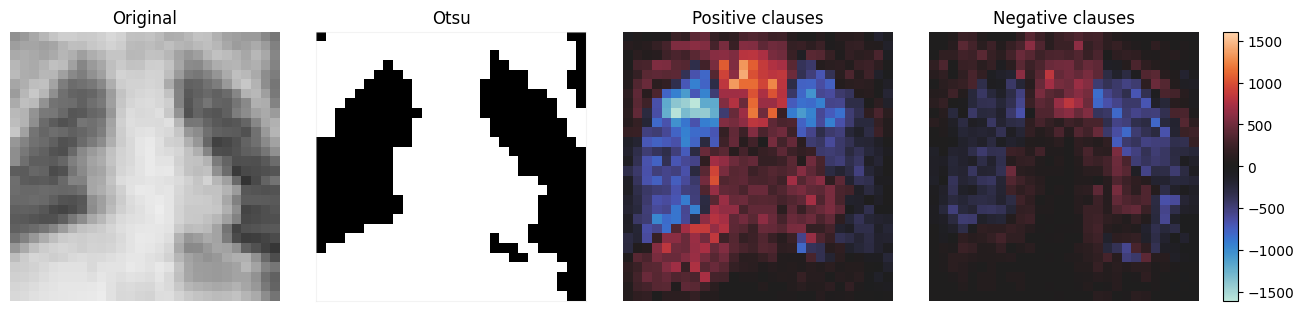

In [13]:
image_index =  344
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

1
Visualizing sample 295  |  predicted class: 1
2026-04-10 15:29:17,061 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x75ca4a49dee0>
Saved to saved_heatmaps/otsu/pneumonia_otsu_lh_c1_s295_aggr.svg


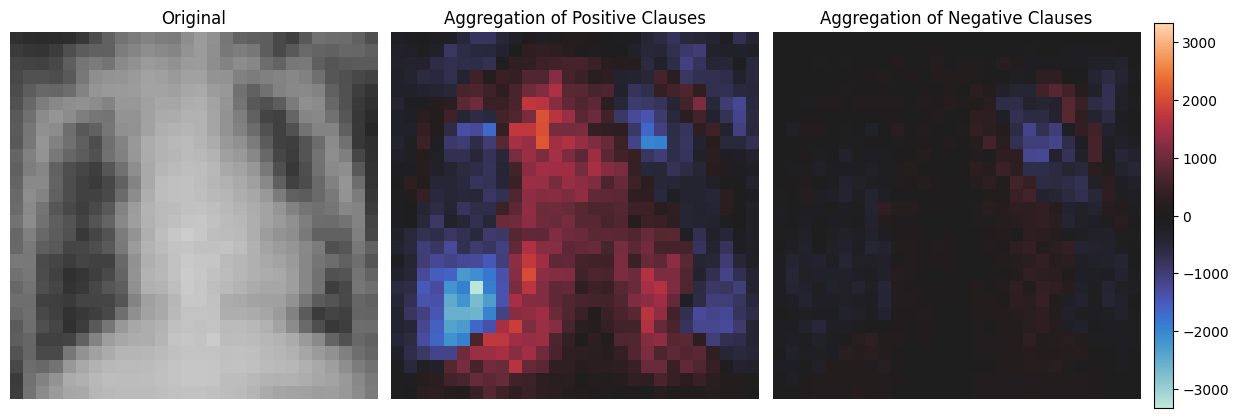

Visualizing sample 295  |  predicted class: 1
2026-04-10 15:29:20,662 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x75ca4a556e40>
Saved to saved_heatmaps/otsu/pneumonia_otsu_lh_c1_s295_chan.svg


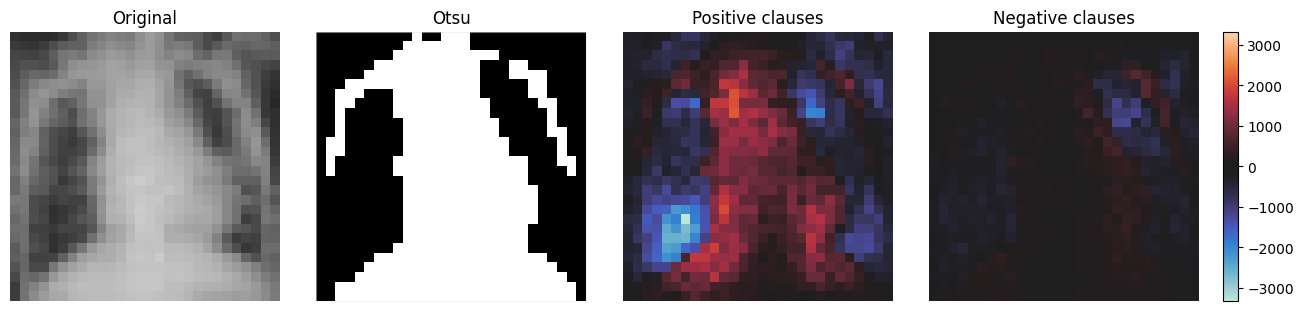

In [14]:
image_index =  295
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

# Global Heatmap 0

Averaging over 159 correctly predicted samples of class 0
  processed 100/159
2026-04-06 16:40:09,121 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x784400ab4aa0>


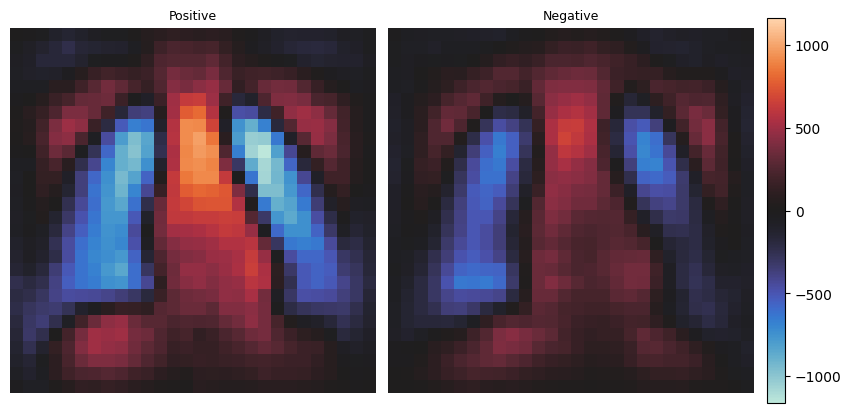

In [14]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 0

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:15:08,579 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 19:15:08,582 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 19:15:08,608 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70d8b483b050>
Saved to saved_heatmaps/otsu/pneumonia_otsu_gh_c0.svg


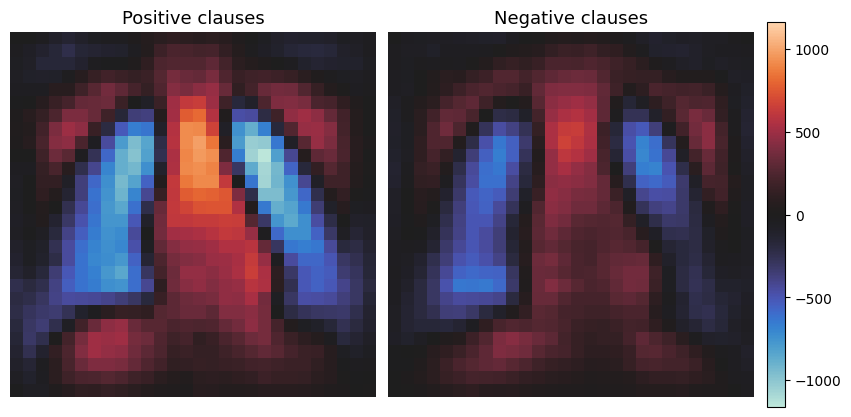

pos shape: (28, 28), min: -1161.80, max: 981.14
neg shape: (28, 28), min: -706.81, max: 669.58
saved_heatmaps/otsu/pneumonia_otsu_gh_c0.svg


In [7]:
target_class = 0
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

# Global Heatmap 1 

Averaging over 383 correctly predicted samples of class 1
  processed 100/383
  processed 200/383
  processed 300/383
2026-04-06 16:59:02,627 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78441a3e3bf0>


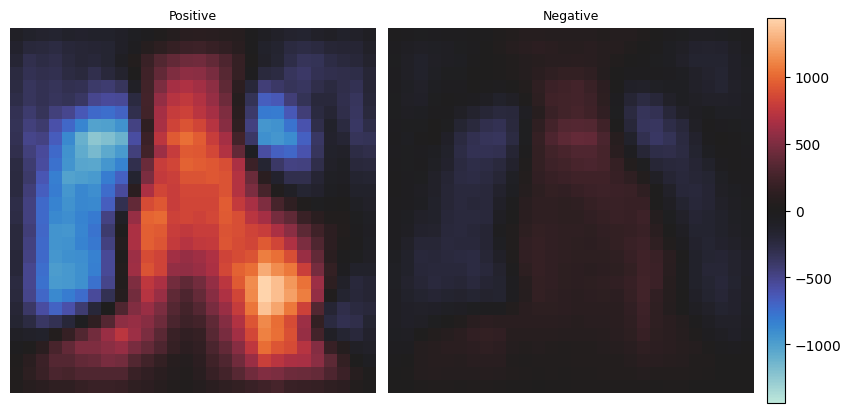

In [16]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 1

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:15:12,423 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70d8afccfa10>
Saved to saved_heatmaps/otsu/pneumonia_otsu_gh_c1.svg


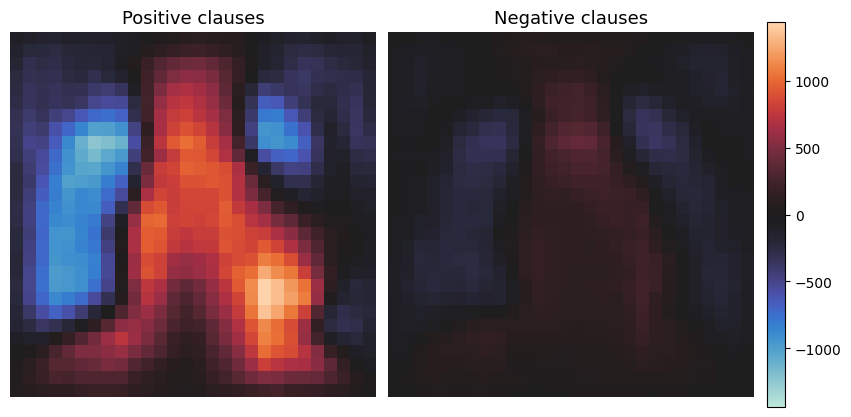

pos shape: (28, 28), min: -1241.87, max: 1437.85
neg shape: (28, 28), min: -375.05, max: 393.21
saved_heatmaps/otsu/pneumonia_otsu_gh_c1.svg


In [8]:
target_class = 1
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)